In [1]:
import pandas as pd

df = pd.read_csv('../data/customer_transactions.csv')

df.head()

,InvoiceID,CustomerID,InvoiceDate,ProductCategory,Quantity,UnitPrice,Discount,TotalAmount,Country,PaymentMethod
0,INV0021743,C00001,2026-03-02,Sports,1,1916.87,0.154,1621.94,India,UPI
1,INV0011210,C00001,2026-03-30,Beauty,3,682.92,0.180,1679.70,India,Cash on Delivery
2,INV0005218,C00001,2026-06-01,Beauty,3,2404.31,0.004,7187.33,UK,Credit Card
3,INV0013984,C00001,2026-06-20,Sports,3,2018.08,0.188,4913.53,India,UPI
4,INV0014055,C00001,2026-06-24,Grocery,2,713.38,0.024,1392.83,India,Cash on Delivery


In [14]:
print(df.shape)

(25075, 10)


In [13]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 25075 entries, 0 to 25074
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   InvoiceID        25075 non-null  str    
 1   CustomerID       25075 non-null  str    
 2   InvoiceDate      25075 non-null  str    
 3   ProductCategory  25075 non-null  str    
 4   Quantity         25075 non-null  int64  
 5   UnitPrice        25075 non-null  float64
 6   Discount         25075 non-null  float64
 7   TotalAmount      25075 non-null  float64
 8   Country          24925 non-null  str    
 9   PaymentMethod    24975 non-null  str    
dtypes: float64(3), int64(1), str(6)
memory usage: 1.9 MB
None


In [16]:
print(df.isnull().sum())
print("\n")
print(df.duplicated().sum())

InvoiceID            0
CustomerID           0
InvoiceDate          0
ProductCategory      0
Quantity             0
UnitPrice            0
Discount             0
TotalAmount          0
Country            150
PaymentMethod      100
dtype: int64


75


In [17]:
print(df.describe())

           Quantity     UnitPrice      Discount    TotalAmount
count  25075.000000  25075.000000  25075.000000   25075.000000
mean       3.685743   1832.179296      0.111380    6058.532790
std        1.809964   2439.680961      0.071485    9671.336198
min        1.000000     30.000000      0.000000      33.580000
25%        2.000000    485.260000      0.050000    1277.920000
50%        3.000000   1056.250000      0.102000    3023.100000
75%        5.000000   2191.445000      0.171000    6904.030000
max       14.000000  45000.000000      0.250000  223758.750000


In [24]:
#Convert InvoiceDate
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])


#Handle missing values
df["Country"] = df["Country"].fillna(df["Country"].mode()[0])

df["PaymentMethod"] = df["PaymentMethod"].fillna(
    df["PaymentMethod"].mode()[0]
)


#Remove duplicate rows
df = df.drop_duplicates()


#Check again
print(df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nData Types:")
print(df.dtypes)

(25000, 10)

Missing Values:
InvoiceID          0
CustomerID         0
InvoiceDate        0
ProductCategory    0
Quantity           0
UnitPrice          0
Discount           0
TotalAmount        0
Country            0
PaymentMethod      0
dtype: int64

Duplicate Rows:
0

Data Types:
InvoiceID                     str
CustomerID                    str
InvoiceDate        datetime64[us]
ProductCategory               str
Quantity                    int64
UnitPrice                 float64
Discount                  float64
TotalAmount               float64
Country                       str
PaymentMethod                 str
dtype: object


In [27]:
print("Unique Customers:", df["CustomerID"].nunique())

Unique Customers: 2394


In [28]:
print("Unique Customers transactions:", df["CustomerID"].value_counts())

Unique Customers transactions: CustomerID
C00723    37
C00395    34
C00812    34
C01261    34
C01309    34
          ..
C02381     1
C02436     1
C02467     1
C02485     1
C02495     1
Name: count, Length: 2394, dtype: int64


In [29]:
print("Start Date:", df["InvoiceDate"].min())
print("End Date:", df["InvoiceDate"].max())

Start Date: 2025-04-01 00:00:00
End Date: 2026-09-14 00:00:00


In [30]:
print(df["ProductCategory"].value_counts())

ProductCategory
Grocery           4476
Fashion           3986
Home & Kitchen    3780
Electronics       3706
Accessories       2560
Beauty            2528
Sports            1993
Books             1971
Name: count, dtype: int64


In [31]:
print(df["Country"].value_counts())

Country
India        19565
UAE           1764
Nepal         1477
Singapore     1202
UK             992
Name: count, dtype: int64


In [32]:
print(df["PaymentMethod"].value_counts())

PaymentMethod
UPI                 9994
Credit Card         6373
Debit Card          3941
Net Banking         3025
Cash on Delivery    1667
Name: count, dtype: int64


In [33]:
print("Total Revenue:", df["TotalAmount"].sum())
print("Average Transaction:", df["TotalAmount"].mean())
print("Median Transaction:", df["TotalAmount"].median())

Total Revenue: 151420713.02
Average Transaction: 6056.828520800001
Median Transaction: 3021.25


In [34]:
customer_spending = (
    df.groupby("CustomerID")["TotalAmount"]
      .sum()
      .sort_values(ascending=False)
)

print(customer_spending.head(10))

CustomerID
C00287    405348.69
C02350    404372.75
C00395    397271.85
C00683    393868.99
C01236    371559.71
C02379    350235.65
C01743    344507.25
C02152    343411.52
C00364    341636.03
C00812    335263.30
Name: TotalAmount, dtype: float64


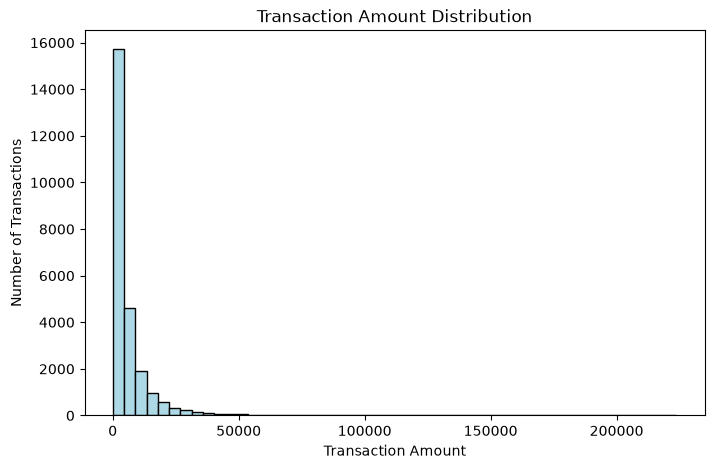

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(
    df["TotalAmount"].dropna(),
    bins=50,
    color="lightblue",
    edgecolor="black"
)

plt.xlabel("Transaction Amount")
plt.ylabel("Number of Transactions")
plt.title("Transaction Amount Distribution")
plt.tight_layout()

plt.show()

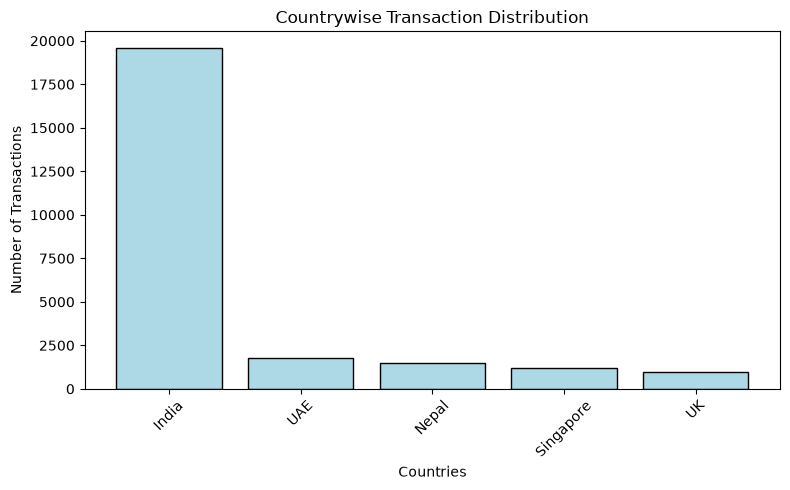

In [61]:
country_counts = df["Country"].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(country_counts.index, country_counts.values,
    color="lightblue", edgecolor="black")

plt.xlabel("Countries")
plt.ylabel("Number of Transactions")
plt.title("Countrywise Transaction Distribution")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [42]:
df.columns

Index(['InvoiceID', 'CustomerID', 'InvoiceDate', 'ProductCategory', 'Quantity',
       'UnitPrice', 'Discount', 'TotalAmount', 'Country', 'PaymentMethod'],
      dtype='str')

In [43]:
print(df["InvoiceDate"].max())

2026-09-14 00:00:00
